In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
df = pd.read_excel('solar_panel_dust_data.xlsx')

# Drop unnecessary columns
df_model = df.drop(['panel_id', 'panel_type'], axis=1)

# Create features for maintenance scheduling
df_model['rainfall_effect'] = df_model['rainfall'] * 0.8  # Rain cleans 80% of dust
df_model['remaining_dust'] = np.maximum(0, df_model['dust_accumulation'] - df_model['rainfall_effect'])
df_model['needs_cleaning'] = (df_model['remaining_dust'] > 15).astype(int)  # Threshold for cleaning
df_model['days_since_last_rain'] = 30 / (df_model['rainfall'] + 1)  # Proxy feature

# Split features and target
X = df_model.drop(['efficiency_drop', 'dust_accumulation', 'needs_cleaning'], axis=1)
y_efficiency = df_model['efficiency_drop']
y_maintenance = df_model['needs_cleaning']

# Train-test split
X_train, X_test, y_eff_train, y_eff_test, y_maint_train, y_maint_test = train_test_split(
    X, y_efficiency, y_maintenance, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [2]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_eff_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'MAE': mean_absolute_error(y_eff_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_eff_test, y_pred)),
        'R2': r2_score(y_eff_test, y_pred)
    }

# Display results
print("Efficiency Drop Prediction Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

# Feature importance (using best model)
best_model = XGBRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_eff_train)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Important Features for Efficiency Drop:")
print(feature_importance.head())

Efficiency Drop Prediction Results:

Random Forest:
  MAE: 0.4383
  RMSE: 0.5329
  R2: 0.8982

XGBoost:
  MAE: 0.4515
  RMSE: 0.5809
  R2: 0.8790

Gradient Boosting:
  MAE: 0.4273
  RMSE: 0.5452
  R2: 0.8934

Ridge Regression:
  MAE: 0.4393
  RMSE: 0.5488
  R2: 0.8920

Top 5 Important Features for Efficiency Drop:
          feature  importance
8  remaining_dust    0.896389
4        humidity    0.061010
6        rainfall    0.013971
5      wind_speed    0.011425
2  sunlight_hours    0.004740


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split for maintenance prediction
X_maint_train, X_maint_test, y_maint_train, y_maint_test = train_test_split(
    X, y_maintenance, test_size=0.2, random_state=42
)

# Scale features
X_maint_train_scaled = scaler.fit_transform(X_maint_train)
X_maint_test_scaled = scaler.transform(X_maint_test)

# Train maintenance classifier
maint_model = RandomForestClassifier(n_estimators=100, random_state=42)
maint_model.fit(X_maint_train_scaled, y_maint_train)

# Predict and evaluate
y_maint_pred = maint_model.predict(X_maint_test_scaled)

print("\nMaintenance Scheduling Model Performance:")
print(f"Accuracy: {accuracy_score(y_maint_test, y_maint_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_maint_test, y_maint_pred))

# Maintenance scheduling rules based on rainfall
def calculate_maintenance_schedule(row):
    """Calculate when maintenance is needed based on environmental factors"""

    # Rule 1: High dust accumulation
    if row['dust_accumulation'] > 20:
        return "URGENT: Clean within 3 days"

    # Rule 2: Moderate dust with no recent rain
    elif row['dust_accumulation'] > 15 and row['rainfall'] < 5:
        return "SCHEDULE: Clean within 7 days"

    # Rule 3: Recent heavy rain (self-cleaning)
    elif row['rainfall'] > 15:
        return "NO CLEANING NEEDED: Recent heavy rain"

    # Rule 4: Normal conditions
    elif row['dust_accumulation'] > 10 and row['rainfall'] < 10:
        return "MONITOR: Check in 14 days"

    else:
        return "NO ACTION: Normal conditions"


Maintenance Scheduling Model Performance:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        20

    accuracy                           1.00       110
   macro avg       1.00      1.00      1.00       110
weighted avg       1.00      1.00      1.00       110



In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

class SolarPanelAnomalyDetector:
    def __init__(self):
        self.anomaly_model = IsolationForest(contamination=0.1, random_state=42)
        self.scaler = StandardScaler()

    def fit(self, X):
        """Train anomaly detection model"""
        X_scaled = self.scaler.fit_transform(X)
        self.anomaly_model.fit(X_scaled)

    def predict(self, X):
        """Predict anomalies (-1 for anomaly, 1 for normal)"""
        X_scaled = self.scaler.transform(X)
        return self.anomaly_model.predict(X_scaled)

    def get_anomaly_scores(self, X):
        """Get anomaly scores (lower = more anomalous)"""
        X_scaled = self.scaler.transform(X)
        return self.anomaly_model.score_samples(X_scaled)

# Initialize and train anomaly detector
anomaly_detector = SolarPanelAnomalyDetector()
anomaly_detector.fit(X)

# Detect anomalies
anomaly_predictions = anomaly_detector.predict(X)
anomaly_scores = anomaly_detector.get_anomaly_scores(X)

# Add to dataframe
df['anomaly_score'] = anomaly_scores
df['is_anomaly'] = (anomaly_predictions == -1)

print(f"\nDetected {df['is_anomaly'].sum()} anomalous panels out of {len(df)}")


Detected 55 anomalous panels out of 550


In [5]:
class SolarPanelMonitoringSystem:
    def __init__(self):
        self.efficiency_model = XGBRegressor(n_estimators=100, random_state=42)
        self.maintenance_model = RandomForestClassifier(n_estimators=100, random_state=42)
        self.anomaly_detector = SolarPanelAnomalyDetector()
        self.scaler = StandardScaler()

    def train(self, X, y_efficiency, y_maintenance):
        """Train all models"""
        # Scale data
        X_scaled = self.scaler.fit_transform(X)

        # Train efficiency model
        self.efficiency_model.fit(X_scaled, y_efficiency)

        # Train maintenance model
        self.maintenance_model.fit(X_scaled, y_maintenance)

        # Train anomaly detector
        self.anomaly_detector.fit(X)

    def predict(self, new_data):
        """Make predictions for new solar panel data"""
        # Prepare input
        X_new = pd.DataFrame([new_data])

        # Scale
        X_scaled = self.scaler.transform(X_new)

        # Predict efficiency drop
        efficiency_drop = self.efficiency_model.predict(X_scaled)[0]

        # Predict maintenance need
        maintenance_needed = self.maintenance_model.predict(X_scaled)[0]

        # Detect anomaly
        anomaly_score = self.anomaly_detector.get_anomaly_scores(X_new)[0]
        is_anomaly = anomaly_score < -0.5  # Threshold for anomaly

        # Get maintenance recommendation
        maintenance_recommendation = calculate_maintenance_schedule(new_data)

        return {
            'predicted_efficiency_drop': float(efficiency_drop),
            'maintenance_needed': bool(maintenance_needed),
            'anomaly_detected': bool(is_anomaly),
            'anomaly_score': float(anomaly_score),
            'maintenance_recommendation': maintenance_recommendation,
            'risk_level': self._calculate_risk_level(efficiency_drop, anomaly_score)
        }

    def _calculate_risk_level(self, efficiency_drop, anomaly_score):
        """Calculate risk level based on predictions"""
        if efficiency_drop > 5 and anomaly_score < -0.7:
            return "HIGH"
        elif efficiency_drop > 3 or anomaly_score < -0.5:
            return "MEDIUM"
        else:
            return "LOW"

# Initialize and train the complete system
monitoring_system = SolarPanelMonitoringSystem()
monitoring_system.train(X, y_efficiency, y_maintenance)

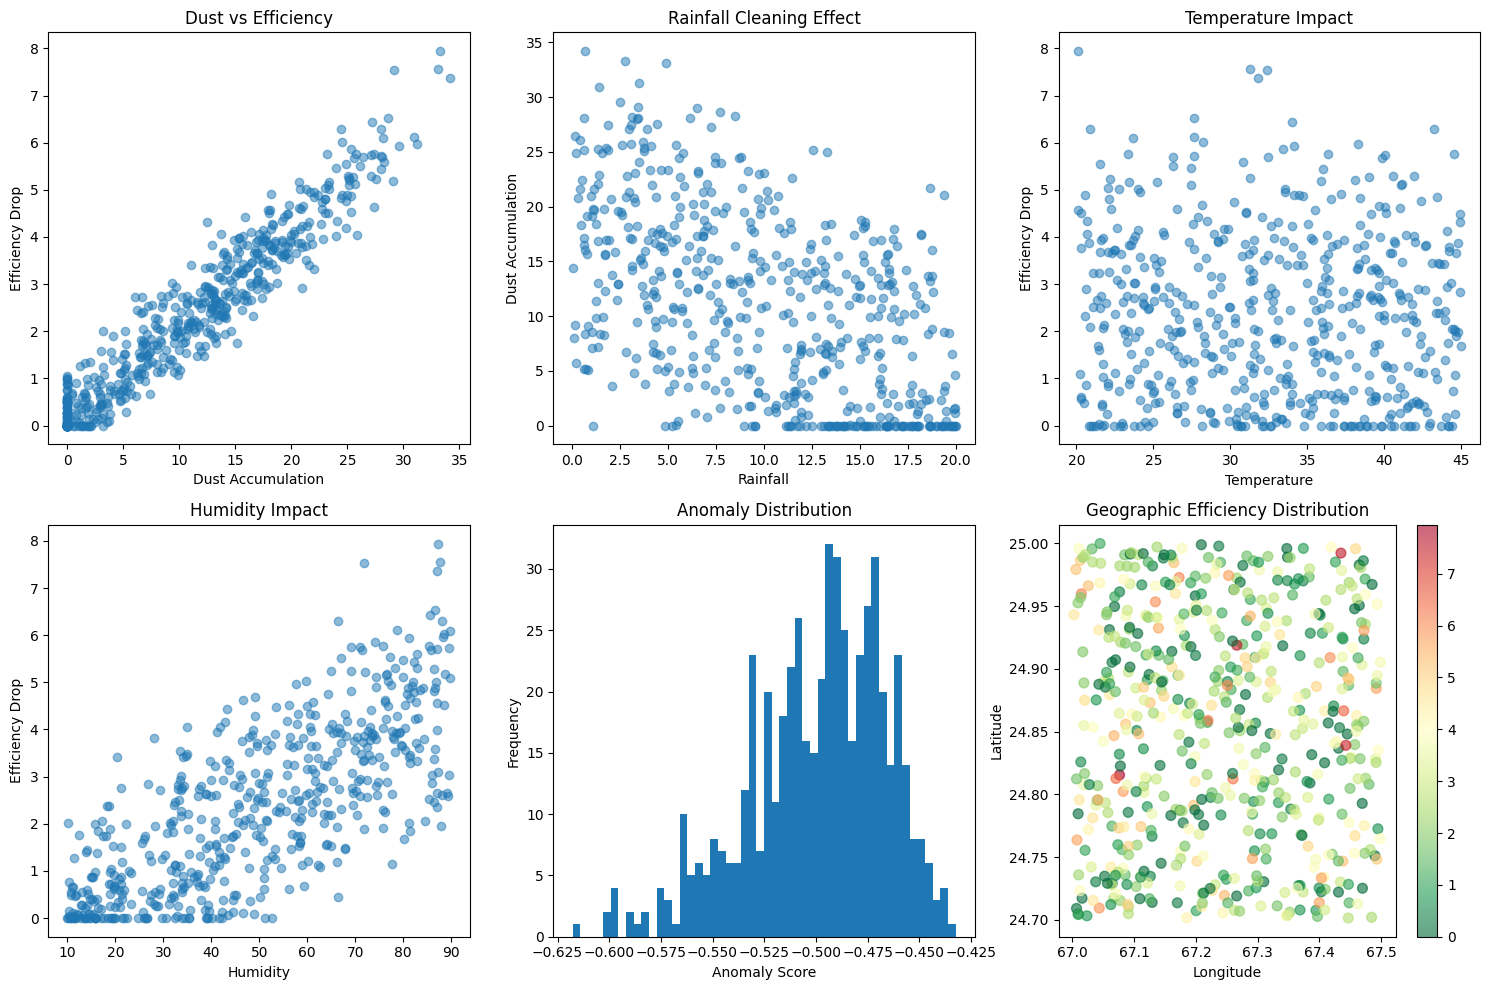

In [6]:
def create_dashboard(df):
    """Create visualization dashboard for monitoring"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. Efficiency vs Dust
    axes[0, 0].scatter(df['dust_accumulation'], df['efficiency_drop'], alpha=0.5)
    axes[0, 0].set_xlabel('Dust Accumulation')
    axes[0, 0].set_ylabel('Efficiency Drop')
    axes[0, 0].set_title('Dust vs Efficiency')

    # 2. Rainfall vs Dust
    axes[0, 1].scatter(df['rainfall'], df['dust_accumulation'], alpha=0.5)
    axes[0, 1].set_xlabel('Rainfall')
    axes[0, 1].set_ylabel('Dust Accumulation')
    axes[0, 1].set_title('Rainfall Cleaning Effect')

    # 3. Temperature vs Efficiency
    axes[0, 2].scatter(df['temperature'], df['efficiency_drop'], alpha=0.5)
    axes[0, 2].set_xlabel('Temperature')
    axes[0, 2].set_ylabel('Efficiency Drop')
    axes[0, 2].set_title('Temperature Impact')

    # 4. Humidity vs Efficiency
    axes[1, 0].scatter(df['humidity'], df['efficiency_drop'], alpha=0.5)
    axes[1, 0].set_xlabel('Humidity')
    axes[1, 0].set_ylabel('Efficiency Drop')
    axes[1, 0].set_title('Humidity Impact')

    # 5. Anomaly distribution
    axes[1, 1].hist(df['anomaly_score'], bins=50)
    axes[1, 1].set_xlabel('Anomaly Score')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Anomaly Distribution')

    # 6. Maintenance needs by location
    if 'latitude' in df.columns and 'longitude' in df.columns:
        scatter = axes[1, 2].scatter(df['longitude'], df['latitude'],
                                     c=df['efficiency_drop'], cmap='RdYlGn_r',
                                     alpha=0.6, s=50)
        axes[1, 2].set_xlabel('Longitude')
        axes[1, 2].set_ylabel('Latitude')
        axes[1, 2].set_title('Geographic Efficiency Distribution')
        plt.colorbar(scatter, ax=axes[1, 2])

    plt.tight_layout()
    plt.show()

# Create dashboard
create_dashboard(df)

In [7]:
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)

# Save trained model
joblib.dump(monitoring_system, 'solar_panel_monitor.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    """API endpoint for predictions"""
    data = request.json

    # Load model
    model = joblib.load('solar_panel_monitor.pkl')

    # Make prediction
    prediction = model.predict(data)

    return jsonify(prediction)

@app.route('/maintenance_schedule', methods=['GET'])
def maintenance_schedule():
    """Get maintenance schedule recommendations"""
    # Analyze all panels and return maintenance schedule
    maintenance_list = []

    for idx, row in df.iterrows():
        if row['needs_cleaning']:
            maintenance_list.append({
                'panel_id': int(row['panel_id']),
                'priority': 'HIGH' if row['efficiency_drop'] > 5 else 'MEDIUM',
                'recommended_date': 'ASAP' if row['dust_accumulation'] > 20 else 'Within 7 days',
                'location': {
                    'latitude': float(row['latitude']),
                    'longitude': float(row['longitude'])
                }
            })

    return jsonify({
        'total_panels': len(df),
        'need_maintenance': len(maintenance_list),
        'maintenance_schedule': maintenance_list
    })